In [8]:
import pandas as pd
df=pd.read_csv("earthquake_1995-2023.csv")
print("rows and columns:",df.shape)
df.head()
df.info()

rows and columns: (1000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64

In [9]:
print("exact duplicate rows:",df.duplicated().sum())

exact duplicate rows: 0


In [11]:
print("First 5 records:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

First 5 records:


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN



Dataset shape:
(998, 19)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      998 non-null    object 
 1   magnitude  998 non-null    float64
 2   date_time  998 non-null    object 
 3   cdi        998 non-null    int64  
 4   mmi        998 non-null    int64  
 5   alert      449 non-null    object 
 6   tsunami    998 non-null    int64  
 7   sig        998 non-null    int64  
 8   net        998 non-null    object 
 9   nst        998 non-null    int64  
 10  dmin       998 non-null    float64
 11  gap        998 non-null    float64
 12  magType    998 non-null    object 
 13  depth      998 non-null    float64
 14  latitude   998 non-null    float64
 15  longitude  998 non-null    float64
 16  location   992 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes:

In [10]:
before=len(df)
df= df.drop_duplicates(subset= ["title","date_time"],keep="first").reset_index(drop=True)
after=len(df)

print(f"Removed {before-after} duplicate row(s).")
print("Rows now:",after)

Removed 2 duplicate row(s).
Rows now: 998


In [12]:
# Count fully identical duplicates
full_duplicates = df.duplicated().sum()
print("Fully identical duplicates:", full_duplicates)

# Count duplicate earthquakes using title + date_time
key_duplicates = df.duplicated(
    subset=["title", "date_time"]
).sum()

print("Duplicate earthquakes based on title + date_time:", key_duplicates)



Fully identical duplicates: 0
Duplicate earthquakes based on title + date_time: 0


In [13]:
missing_report = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing_report)

,Missing Count,Missing Percentage
title,0,0.00
magnitude,0,0.00
date_time,0,0.00
cdi,0,0.00
mmi,0,0.00
alert,549,55.01
tsunami,0,0.00
sig,0,0.00
net,0,0.00
nst,0,0.00


In [ ]:
import numpy as np
for col in["cdi","gap"]:
  df[col]=df[col].replace(0,np.nan)

  print("missing values now visible:")
  print(df[["cdi","gap"]].isnull().sum())

missing values now visible:
cdi    395
gap      0
dtype: int64
missing values now visible:
cdi    395
gap    252
dtype: int64


In [16]:
import numpy as np
zero_as_missing = ["cdi", "gap", "nst", "dmin"]

for col in zero_as_missing:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

print("Placeholder zeros converted to NaN.")

Placeholder zeros converted to NaN.


In [17]:
print("Magnitude skewness:", df["magnitude"].skew())
print("Gap skewness:", df["gap"].skew())

Magnitude skewness: 1.3665595466049707
Gap skewness: 4.885701324053703


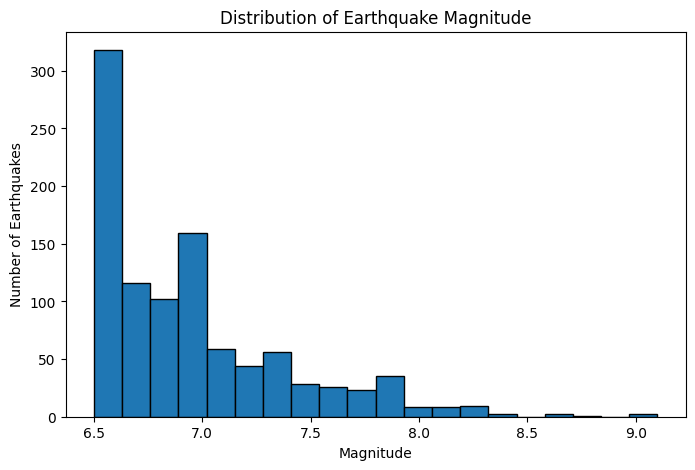

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["magnitude"].dropna(), bins=20, edgecolor="black")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Distribution of Earthquake Magnitude")
plt.show()

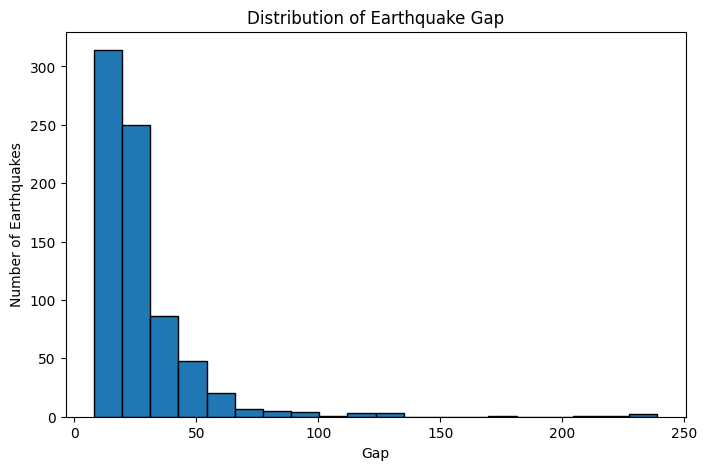

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["gap"].dropna(), bins=20, edgecolor="black")
plt.xlabel("Gap")
plt.ylabel("Number of Earthquakes")
plt.title("Distribution of Earthquake Gap")
plt.show()

In [21]:
df.to_csv("earthquake_19952023_cleaned.csv", index=False)

print("Cleaned CSV created successfully!")


Cleaned CSV created successfully!


In [22]:
from google.colab import files

files.download("earthquake_19952023_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>